# Step 4 — Solar Resource & PV/Battery Sizing

This notebook starts with **solar resource data** — getting an hourly global irradiance profile G(i), in W/m2, for the project site — before moving on to Ppeak, Egen, and battery sizing (added in later chunks, once this part is confirmed).

**Design, per your instructions:** the app should only ever need **latitude and longitude** from the user. It should connect to a real, free, no-signup irradiance data source by default, let the user switch to a different data source (including their own API key for a provider that requires one), and always allow a straight Excel upload as a manual alternative. Concretely, this section builds:

1. A **default/offline dataset** — this project's own site's hourly irradiance, extracted directly from the source workbook (`Base-Calculations-00.xlsx`, Annex-IV column G), so the app always has *something* to show even with no network access at all.
2. Two **built-in, no-signup API sources** — see the research note below for why these two and not something else.
3. A **custom API slot** — for a provider that needs a signup + API key (e.g. Solcast), configured through a small `data/solar-api.txt` file rather than hard-coded.
4. An **Excel upload/download** path, matching every other editable dataset in this project.
5. One accessor function, `get_solar_resource()`, that ties all four together with a graceful fallback if a live call fails.

### Research note: which API, and does it need a signup?

Two irradiance data sources are genuinely free, well-established, and need **no signup or API key at all**:

- **PVGIS** (EU Joint Research Centre's *Photovoltaic Geographical Information System*) — `https://re.jrc.ec.europa.eu/api/v5_3/`. This is the most widely used solar-resource tool specifically *for PV project design* worldwide (it's what `pvlib`, the standard Python PV modeling library, has built-in support for) — it even has a dedicated off-grid-with-battery calculator (`SHScalc`) alongside the plain irradiance series (`seriescalc`) used here. No key needed; rate limit is 30 requests/second/IP. Coverage: Europe, Africa, and most of Asia at high resolution (SARAH3 database), the Americas between 60°N-20°S at slightly different resolution (NSRDB database) — it does **not** cover Australia/NZ/the Pacific or the far north.
- **NASA POWER** (`https://power.larc.nasa.gov/api/`) — genuinely **global** coverage, also free, also no key. Slightly coarser resolution (~0.5-1° grid) than PVGIS.

**Decision:** PVGIS is the default (it's the field-standard tool for exactly this use case), with NASA POWER as the automatic fallback for sites outside PVGIS's coverage area. **Neither needs an account, so there's nothing for you to sign up for to use the app's defaults.**

The one case where a signup *would* be needed is a paid, higher-accuracy commercial provider — e.g. **Solcast**, which has a limited free trial and then a paid plan, and does require an API key. That's exactly what the "custom" source slot and `data/solar-api.txt` below are for, if you ever want to add one: create the account, get the key, and drop it in that file — nothing in the notebook or app code needs to change.

## 4.1 Setup

In [1]:
import pandas as pd  # pandas: tabular data (DataFrames)
import numpy as np  # numpy: numerical operations
import requests  # requests: makes the HTTP calls to the solar irradiance APIs
import re  # re: parses the timestamp strings the APIs return
from pathlib import Path  # Path: OS-independent file paths

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()  # find the project's root folder regardless of where the notebook is run from
DATA_DIR = PROJECT_ROOT / "data"  # the shared data/ folder used by every notebook

SOURCE_WORKBOOK = PROJECT_ROOT / "Base-Calculations-00.xlsx"  # the renamed reference workbook
if not SOURCE_WORKBOOK.exists():
    SOURCE_WORKBOOK = Path("/mnt/user-data/uploads/Rural Electrification/Base-Calculations.xlsx")  # fall back to the uploads copy used during development

# Default project site: Shamspir (Shams Pir Island), Keamari, Karachi — the coastal Pakistan-like site this
# reference workbook is built around. This is only a starting default; the app's whole point is that the user
# can change lat/lon to their own project site and everything below recomputes from that.
DEFAULT_LAT = 24.843   # degrees N (source: Wikipedia, Shamspir coordinates 24°50'35"N)
DEFAULT_LON = 66.919   # degrees E (source: Wikipedia, Shamspir coordinates 66°55'10"E)

print("Source workbook:", SOURCE_WORKBOOK, "  exists:", SOURCE_WORKBOOK.exists())
print(f"Default site: {DEFAULT_LAT}, {DEFAULT_LON}")

Source workbook: /home/claude/rural-electrification/Base-Calculations-00.xlsx   exists: True
Default site: 24.843, 66.919


## 4.2 Default/offline dataset — this site's own irradiance, from the workbook

Annex-IV column G (`G(i) W/m2`) already has a full 8,760-hour irradiance series pasted into it as raw values — presumably originally pulled from a source like this for the same site. Extracting it (the same `openpyxl` technique used for every other Annex in this project) gives a real, ready-to-use default dataset, so the app has something to show immediately, works fully offline, and gives every later PV/battery calculation something to validate against.

In [2]:
import openpyxl  # openpyxl: reads the source .xlsx workbook directly

wb = openpyxl.load_workbook(SOURCE_WORKBOOK, data_only=True, read_only=True)  # data_only=True: read the pasted values, not formulas
ws = wb["Annex-IV"]

# Column B = Hour (1-8760), Column G = G(i) W/m2 — rows 7 to 8766 are the 8,760 data rows (row 8767 is a totals row)
rows = list(ws.iter_rows(min_row=7, max_row=8766, min_col=2, max_col=7, values_only=True))  # iter_rows(): one sequential pass, fast even in read_only mode
wb.close()  # close(): release the file handle now that we've read what we need

default_irradiance = pd.DataFrame(rows, columns=["hour_of_year", "weekday_name", "clock", "week", "month", "ghi_wm2"])  # build a tidy DataFrame from the raw tuples
default_irradiance = default_irradiance[["hour_of_year", "ghi_wm2"]]  # keep just what's needed — the rest duplicates hour_skeleton from Step 2

print(f"Extracted {len(default_irradiance)} hours; peak {default_irradiance['ghi_wm2'].max():.1f} W/m2, annual sum {default_irradiance['ghi_wm2'].sum():,.0f} Wh/m2/yr")
default_irradiance.to_csv(DATA_DIR / "default_irradiance_2026.csv", index=False)  # to_csv(): save as this project's default/offline irradiance dataset
print("Saved to:", (DATA_DIR / "default_irradiance_2026.csv").resolve())
default_irradiance.head(3)

Extracted 8760 hours; peak 1062.2 W/m2, annual sum 2,258,720 Wh/m2/yr
Saved to: /home/claude/rural-electrification/data/default_irradiance_2026.csv


,hour_of_year,ghi_wm2
0,1,0.0
1,2,0.0
2,3,0.0


## 4.3 Mapping an arbitrary fetched year onto this project's 365-day calendar

Both live APIs return data for a specific **historical** year (e.g. 2020), by real calendar date. This project's calendar (Steps 1-3) is a generic, non-leap 365-day year addressed by `hour_of_year`. This helper maps any fetched (month, day, hour) onto this project's `hour_of_year` — used by both fetch functions below, so they return data in exactly the same shape as `default_irradiance` above.

In [3]:
# A fixed (month, day, hour) -> hour_of_year lookup for this project's non-leap 365-day year, reused by
# every "fetch from a real historical year" function below, so an API's calendar year is irrelevant to us —
# only the month/day/hour repeating pattern is.
_YEAR_DATES = pd.date_range("2026-01-01", periods=365, freq="D")  # date_range(): the same 365-day year Step 2 uses
MONTH_DAY_HOUR_TO_HOUR_OF_YEAR = {  # dict comprehension: build the (month, day, hour) -> hour_of_year lookup once
    (d.month, d.day, h): (i * 24) + h + 1
    for i, d in enumerate(_YEAR_DATES) for h in range(24)
}


def standardize_to_project_year(df: pd.DataFrame, month_col: str, day_col: str, hour_col: str, value_col: str) -> pd.DataFrame:
    """Map a (month, day, hour, value) table from any real calendar year onto this project's hour_of_year (1-8760).
    Feb 29 (leap years) is dropped, since this project's calendar has no leap day. If more than one source year
    is present, values for the same (month, day, hour) are averaged."""
    df = df[~((df[month_col] == 2) & (df[day_col] == 29))].copy()  # drop Feb 29 — not part of this project's 365-day year
    df["hour_of_year"] = df.apply(lambda r: MONTH_DAY_HOUR_TO_HOUR_OF_YEAR.get((r[month_col], r[day_col], r[hour_col])), axis=1)  # apply(): look up each row's hour_of_year
    df = df.dropna(subset=["hour_of_year"])  # dropna(): guard against any (month, day, hour) combination that didn't map (shouldn't normally happen)
    df["hour_of_year"] = df["hour_of_year"].astype(int)
    return df.groupby("hour_of_year", as_index=False)[value_col].mean()  # groupby().mean(): average across source years if more than one was requested

## 4.4 Live API #1 — PVGIS (default)

In [4]:
def fetch_pvgis_hourly(lat: float, lon: float, year: int = 2020, timeout: int = 30) -> dict:
    """Fetch one year of hourly global irradiance G(i), in W/m2, from PVGIS for the given site.
    Returns {"data": tidy DataFrame [hour_of_year, ghi_wm2], "errors": []} on success,
    or {"data": None, "errors": [...]} if the request fails for any reason (network, bad response, etc)."""
    url = "https://re.jrc.ec.europa.eu/api/v5_3/seriescalc"  # PVGIS's hourly time-series endpoint — no API key required
    params = {"lat": lat, "lon": lon, "startyear": year, "endyear": year, "components": 0, "outputformat": "json"}  # components=0: just total G(i), not split into direct/diffuse/reflected

    try:
        response = requests.get(url, params=params, timeout=timeout)  # get(): the actual HTTP call
        response.raise_for_status()  # raise_for_status(): turn a 4xx/5xx HTTP response into a catchable exception
        payload = response.json()
    except requests.exceptions.RequestException as e:  # catches connection errors, timeouts, DNS failures, bad status codes, etc.
        return {"data": None, "errors": [f"PVGIS request failed: {e}"]}
    except ValueError as e:  # json() raises ValueError if the response body isn't valid JSON
        return {"data": None, "errors": [f"PVGIS returned an unparseable response: {e}"]}

    hourly = payload.get("outputs", {}).get("hourly")  # PVGIS's hourly series lives at outputs.hourly
    if not hourly:
        return {"data": None, "errors": ["PVGIS response had no 'outputs.hourly' data — check lat/lon are within its coverage area"]}

    raw = pd.DataFrame(hourly)  # each row: {"time": "20200101:0010", "G(i)": 0.0, "T2m": ..., ...}
    time_parts = raw["time"].str.extract(r"(?P<year>\d{4})(?P<month>\d{2})(?P<day>\d{2}):(?P<hour>\d{2})")  # extract(): pull year/month/day/hour out of PVGIS's "YYYYMMDD:HHMM" timestamp format
    raw["month"] = time_parts["month"].astype(int)
    raw["day"] = time_parts["day"].astype(int)
    raw["hour"] = time_parts["hour"].astype(int)
    raw["ghi_wm2"] = raw["G(i)"]

    standardized = standardize_to_project_year(raw, "month", "day", "hour", "ghi_wm2")  # call: map onto this project's hour_of_year
    return {"data": standardized, "errors": []}

## 4.5 Live API #2 — NASA POWER (fallback, global coverage)

In [5]:
def fetch_nasa_power_hourly(lat: float, lon: float, year: int = 2020, timeout: int = 60) -> dict:
    """Fetch one year of hourly all-sky surface shortwave irradiance (W/m2) from NASA POWER for the given site.
    Same return shape as fetch_pvgis_hourly(). Used as the fallback for sites outside PVGIS's coverage area."""
    url = "https://power.larc.nasa.gov/api/temporal/hourly/point"  # NASA POWER's hourly point-data endpoint — no API key required
    params = {
        "parameters": "ALLSKY_SFC_SW_DWN",  # the all-sky global horizontal irradiance parameter, in W/m2 for hourly data
        "community": "RE",  # "RE" = renewable energy community preset
        "latitude": lat, "longitude": lon,
        "start": f"{year}0101", "end": f"{year}1231",  # NASA POWER wants YYYYMMDD, not separate year/month/day
        "format": "JSON",
    }

    try:
        response = requests.get(url, params=params, timeout=timeout)
        response.raise_for_status()
        payload = response.json()
    except requests.exceptions.RequestException as e:
        return {"data": None, "errors": [f"NASA POWER request failed: {e}"]}
    except ValueError as e:
        return {"data": None, "errors": [f"NASA POWER returned an unparseable response: {e}"]}

    try:
        series = payload["properties"]["parameter"]["ALLSKY_SFC_SW_DWN"]  # NASA POWER nests the actual values here: {"2020010100": 0.0, "2020010101": ..., ...}
    except KeyError:
        return {"data": None, "errors": ["NASA POWER response was missing the expected data — check lat/lon are valid"]}

    raw = pd.DataFrame({"timestamp": list(series.keys()), "ghi_wm2": list(series.values())})  # timestamp keys are "YYYYMMDDHH"
    raw["month"] = raw["timestamp"].str.slice(4, 6).astype(int)  # slice(): pull month out of the "YYYYMMDDHH" key
    raw["day"] = raw["timestamp"].str.slice(6, 8).astype(int)
    raw["hour"] = raw["timestamp"].str.slice(8, 10).astype(int)
    raw = raw[raw["ghi_wm2"] > -900]  # NASA POWER uses -999 as a "no data" fill value — drop those rows rather than treating them as real zeros

    standardized = standardize_to_project_year(raw, "month", "day", "hour", "ghi_wm2")
    return {"data": standardized, "errors": []}

### Testing the parsing logic offline (mocked responses)

The sandbox network restriction above means the live HTTP call itself was never actually reached — the fetch functions failed at the `requests.get()` line, before any of the response-parsing code ran. That parsing code (extracting the timestamp, mapping onto this project's calendar, averaging across years) is exactly the part most likely to have a bug, so it's tested here directly: `requests.get` is temporarily replaced with a fake that returns a small hand-built response in each provider's real shape (two synthetic years, so the year-averaging path is exercised too), bypassing the network entirely.

In [6]:
from unittest.mock import patch  # patch(): temporarily replace requests.get with a fake, for testing without a network call


class _FakeResponse:
    """A minimal stand-in for requests.Response, just enough for raise_for_status() and json() to work."""
    def __init__(self, payload):
        self._payload = payload

    def raise_for_status(self):  # no-op: a successful fake response never raises
        pass

    def json(self):
        return self._payload


# --- Build a small synthetic PVGIS-shaped response: hour 0 and hour 12 of Jan 1, across two years ---
pvgis_fake_hourly = [
    {"time": "20190101:0010", "G(i)": 0.0},    # 2019, Jan 1, hour 0 -> night, 0 W/m2
    {"time": "20190101:1210", "G(i)": 500.0},  # 2019, Jan 1, hour 12 -> midday, 500 W/m2
    {"time": "20200101:0010", "G(i)": 10.0},   # 2020, Jan 1, hour 0 -> a different value, to test averaging
    {"time": "20200101:1210", "G(i)": 600.0},  # 2020, Jan 1, hour 12
    {"time": "20200229:1210", "G(i)": 999.0},  # 2020 is a leap year — Feb 29 should be dropped entirely
]
with patch("requests.get", return_value=_FakeResponse({"outputs": {"hourly": pvgis_fake_hourly}})):  # patch(): swap in the fake for the duration of this call
    pvgis_test = fetch_pvgis_hourly(DEFAULT_LAT, DEFAULT_LON, year=2020)  # call: lat/lon/year are irrelevant here since the fake ignores them

assert pvgis_test["errors"] == [], f"Unexpected errors: {pvgis_test['errors']}"
pvgis_result = pvgis_test["data"].set_index("hour_of_year")["ghi_wm2"]
assert pvgis_result.loc[1] == (0.0 + 10.0) / 2, "Hour 1 (Jan 1, hour 0) should be the average of the two synthetic years"  # hour_of_year 1 = day 1, hour 0
assert pvgis_result.loc[13] == (500.0 + 600.0) / 2, "Hour 13 (Jan 1, hour 12) should be the average of the two synthetic years"  # hour_of_year 13 = day 1, hour 12
assert len(pvgis_test["data"]) == 2, "Feb 29 should have been dropped, leaving only the two Jan 1 hours"
print("PVGIS parsing test passed: timestamp extraction, hour_of_year mapping, leap-day drop, and cross-year averaging all correct.")

# --- Build a small synthetic NASA POWER-shaped response, same two-year averaging + leap-day-drop check ---
nasa_fake_series = {
    "2019010100": 0.0, "2019010112": 500.0,
    "2020010100": 10.0, "2020010112": 600.0,
    "2020022912": 999.0,  # leap day again, from the other provider's response shape
}
with patch("requests.get", return_value=_FakeResponse({"properties": {"parameter": {"ALLSKY_SFC_SW_DWN": nasa_fake_series}}})):
    nasa_test = fetch_nasa_power_hourly(DEFAULT_LAT, DEFAULT_LON, year=2020)

assert nasa_test["errors"] == [], f"Unexpected errors: {nasa_test['errors']}"
nasa_result = nasa_test["data"].set_index("hour_of_year")["ghi_wm2"]
assert nasa_result.loc[1] == (0.0 + 10.0) / 2, "Hour 1 should be the average of the two synthetic years"
assert nasa_result.loc[13] == (500.0 + 600.0) / 2, "Hour 13 should be the average of the two synthetic years"
assert len(nasa_test["data"]) == 2, "Feb 29 should have been dropped"
print("NASA POWER parsing test passed: timestamp extraction, hour_of_year mapping, leap-day drop, and cross-year averaging all correct.")

# --- Negative test: a request that raises should be caught and reported, not propagated as an uncaught exception ---
with patch("requests.get", side_effect=requests.exceptions.ConnectionError("simulated network failure")):  # side_effect: make the fake call raise, like the real sandbox restriction does
    error_test = fetch_pvgis_hourly(DEFAULT_LAT, DEFAULT_LON)
assert error_test["data"] is None and len(error_test["errors"]) == 1, "A connection failure should be caught and reported, not raised"
print("Negative test passed: a simulated connection failure is caught and reported cleanly, matching what actually happened against the real APIs above.")

PVGIS parsing test passed: timestamp extraction, hour_of_year mapping, leap-day drop, and cross-year averaging all correct.
NASA POWER parsing test passed: timestamp extraction, hour_of_year mapping, leap-day drop, and cross-year averaging all correct.
Negative test passed: a simulated connection failure is caught and reported cleanly, matching what actually happened against the real APIs above.


## 4.6 A custom API slot, configured via `data/solar-api.txt`

For a provider that needs a signup + API key (e.g. Solcast), the base URL and key live in a small plain-text config file rather than in the notebook or app code — so adding one is "create the account, paste the key in the file," not a code change. The file is simple `key = value` lines; a template with the two fields commented out is created below if it doesn't already exist.

In [7]:
SOLAR_API_CONFIG_PATH = DATA_DIR / "solar-api.txt"  # the file the user edits to add a custom provider


def load_custom_api_config(path=SOLAR_API_CONFIG_PATH) -> dict:
    """Parse the simple 'key = value' config file used for a custom solar-irradiance API. Blank/commented lines are ignored."""
    if not path.exists():
        return {}
    config = {}
    for line in path.read_text().splitlines():  # read_text().splitlines(): read the whole small file, one setting per line
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:  # skip blank lines and comments
            continue
        key, _, value = line.partition("=")  # partition(): split "key = value" on the first "="
        config[key.strip()] = value.strip()
    return config


if not SOLAR_API_CONFIG_PATH.exists():  # only create the template if the user hasn't already made their own
    SOLAR_API_CONFIG_PATH.write_text(
        "# solar-api.txt — configuration for a CUSTOM solar irradiance API (optional).\n"
        "# PVGIS and NASA POWER (the app's two built-in sources) need nothing here — this file is only\n"
        "# for adding a THIRD, different provider, e.g. one that requires a paid account and an API key.\n"
        "#\n"
        "# To use one: sign up with the provider, get an API key, then uncomment and fill in the two lines below.\n"
        "# provider_name = Solcast\n"
        "# base_url = https://api.solcast.com.au/data/historic/radiation_and_weather\n"
        "# api_key = your_api_key_here\n"
    )
    print("Created a blank template at:", SOLAR_API_CONFIG_PATH.resolve())

custom_config = load_custom_api_config()  # call: read back whatever is currently in the file (empty on first run, since everything above is commented out)
print("Custom API configured:" if custom_config else "No custom API configured (file is still a blank template) —", custom_config or "this is expected until you add one")

No custom API configured (file is still a blank template) — this is expected until you add one


## 4.7 Excel upload/download — the manual fallback

Same round-trip pattern as every other editable dataset in this project: download a template, fill in (or paste from another tool) an 8,760-row hourly irradiance series, upload it back, with validation before it's accepted.

In [8]:
def export_irradiance_template(irradiance_df: pd.DataFrame, output_path) -> None:
    """Write an hourly irradiance table to a formatted .xlsx template for manual editing or replacement."""
    with pd.ExcelWriter(output_path, engine="xlsxwriter") as writer:  # ExcelWriter(): open a new .xlsx for writing, with formatting support
        workbook = writer.book
        header_fmt = workbook.add_format({"bold": True, "bg_color": "#2a78d6", "font_color": "white", "border": 1})  # same header style used throughout this project

        instructions = pd.DataFrame({"Instructions": [
            "One row per hour of the year (hour_of_year 1-8760, matching every other hourly table in this project).",
            "ghi_wm2 is the global horizontal irradiance for that hour, in W/m2 (0 at night, up to ~1000+ at solar noon on a clear day).",
            "Do not add/remove rows or rename columns — the app matches them by name on re-upload.",
            "Save the file, then re-upload it in the app to use this data instead of the default or a live API fetch.",
        ]})
        instructions.to_excel(writer, sheet_name="Instructions", index=False)
        irradiance_df.to_excel(writer, sheet_name="Irradiance", index=False)  # to_excel(): write the data to its own sheet

        for sheet_name, df in [("Instructions", instructions), ("Irradiance", irradiance_df)]:  # for loop: bold headers + sized columns on every sheet
            ws = writer.sheets[sheet_name]
            for col_idx, col_name in enumerate(df.columns):
                ws.write(0, col_idx, col_name, header_fmt)
                ws.set_column(col_idx, col_idx, max(12, len(str(col_name)) + 2))


def import_irradiance_template(input_path) -> dict:
    """Read a workbook in the export_irradiance_template() shape back into a tidy DataFrame, with validation."""
    errors = []
    sheets = pd.read_excel(input_path, sheet_name=None)  # read_excel(): read every sheet at once

    if "Irradiance" not in sheets:
        return {"data": None, "errors": ["Missing required sheet: 'Irradiance'"]}

    df = sheets["Irradiance"]
    required_cols = ["hour_of_year", "ghi_wm2"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        errors.append(f"'Irradiance' sheet is missing column(s): {missing}")

    if not errors:
        if len(df) != 8760:
            errors.append(f"Expected 8760 rows (one per hour of the year), found {len(df)}")
        if df["hour_of_year"].duplicated().any():  # duplicated(): flag any hour_of_year listed more than once
            errors.append("Duplicate hour_of_year value(s) found")
        if set(df["hour_of_year"]) != set(range(1, 8761)):  # confirm every hour 1-8760 is present, none missing
            errors.append("hour_of_year does not cover exactly 1-8760 with no gaps")
        if (df["ghi_wm2"] < 0).any():
            errors.append("Some ghi_wm2 value(s) are negative, which isn't physically valid")

    if errors:
        return {"data": None, "errors": errors}
    return {"data": df[["hour_of_year", "ghi_wm2"]].sort_values("hour_of_year").reset_index(drop=True), "errors": []}


export_irradiance_template(default_irradiance, DATA_DIR / "Irradiance_Template.xlsx")  # call: write the default dataset out as an editable/replaceable template
print("Saved to:", (DATA_DIR / "Irradiance_Template.xlsx").resolve())

# Round-trip test
_imported = import_irradiance_template(DATA_DIR / "Irradiance_Template.xlsx")
assert _imported["errors"] == [], f"Round-trip import reported errors: {_imported['errors']}"
pd.testing.assert_frame_equal(_imported["data"].reset_index(drop=True), default_irradiance.reset_index(drop=True))  # assert_frame_equal(): exact match, default -> file -> back
print("Round-trip OK: exported default irradiance re-imported with zero errors and an exact match.")

Saved to: /home/claude/rural-electrification/data/Irradiance_Template.xlsx
Round-trip OK: exported default irradiance re-imported with zero errors and an exact match.


## 4.8 One accessor to tie it all together

`get_solar_resource()` is what the rest of this notebook (and the eventual Streamlit page) actually calls. It tries the requested source, and if that fails for any reason (no network, site outside coverage, bad custom-API response), it falls back to the bundled default dataset rather than crashing — with a clearly printed warning, never a silent substitution.

In [9]:
def get_solar_resource(lat: float = DEFAULT_LAT, lon: float = DEFAULT_LON, year: int = 2020,
                        source: str = "pvgis", fallback_to_default: bool = True) -> dict:
    """
    Get an 8,760-hour irradiance profile [hour_of_year, ghi_wm2] for (lat, lon).
    source: "pvgis" (default), "nasa_power", "custom" (reads data/solar-api.txt), or "default" (the bundled dataset, no network).
    Returns {"data": DataFrame, "source_used": str, "errors": [...]} — errors is non-empty only when something
    went wrong along the way (even if a fallback ultimately succeeded, so the caller can still show a warning).
    """
    errors = []

    if source == "default":
        return {"data": default_irradiance.copy(), "source_used": "default (bundled)", "errors": []}

    elif source == "pvgis":
        result = fetch_pvgis_hourly(lat, lon, year)
    elif source == "nasa_power":
        result = fetch_nasa_power_hourly(lat, lon, year)
    elif source == "custom":
        config = load_custom_api_config()
        if not config.get("base_url") or not config.get("api_key"):
            result = {"data": None, "errors": ["No custom API configured — fill in data/solar-api.txt (base_url and api_key) first"]}
        else:
            # Generic pass-through call: works for a provider whose response can be read the same way as PVGIS/NASA POWER;
            # a genuinely different response shape will need a small provider-specific parser added here once you've
            # signed up and we can see the real response format.
            try:
                response = requests.get(config["base_url"], params={"api_key": config["api_key"], "latitude": lat, "longitude": lon}, timeout=30)
                response.raise_for_status()
                result = {"data": None, "errors": [f"Custom API '{config.get('provider_name', 'unknown')}' responded, but this project doesn't yet know how to parse its response format — add a small parser once you've signed up and can see a real response."]}
            except requests.exceptions.RequestException as e:
                result = {"data": None, "errors": [f"Custom API request failed: {e}"]}
    else:
        result = {"data": None, "errors": [f"Unknown source '{source}'. Choose one of: pvgis, nasa_power, custom, default"]}

    if result["data"] is not None:
        return {"data": result["data"], "source_used": source, "errors": result["errors"]}

    errors.extend(result["errors"])
    if fallback_to_default:
        errors.append(f"Falling back to the bundled default irradiance dataset (source '{source}' was unavailable).")
        return {"data": default_irradiance.copy(), "source_used": "default (fallback)", "errors": errors}
    return {"data": None, "source_used": None, "errors": errors}

## 4.9 Demo

Attempting the live PVGIS call for the default site. **Expected outcome in this cloud sandbox:** this environment's outbound network only reaches package registries (pip/npm) for security reasons — it cannot reach `re.jrc.ec.europa.eu` or `power.larc.nasa.gov` at all, so both live calls will fail here with a connection error, and `get_solar_resource()` will fall back to the bundled default dataset. This is a sandbox restriction, not a bug in the fetch functions — they're implemented directly from each provider's official API documentation, and the same call will work normally once this notebook (or the deployed app) runs on your machine or a normal server with outbound internet access. Re-run this cell locally once you have the project set up in VS Code to confirm the live call itself.

In [10]:
result = get_solar_resource(source="pvgis")  # call: try the default source for the default site

print(f"Source used: {result['source_used']}")
if result["errors"]:
    for e in result["errors"]:
        print("  -", e)
print(f"Rows returned: {len(result['data'])}")
result["data"].head(3)

Source used: default (fallback)
  - PVGIS request failed: HTTPSConnectionPool(host='re.jrc.ec.europa.eu', port=443): Max retries exceeded with url: /api/v5_3/seriescalc?lat=24.843&lon=66.919&startyear=2020&endyear=2020&components=0&outputformat=json (Caused by ProxyError('Unable to connect to proxy', OSError('Tunnel connection failed: 403 Forbidden')))
  - Falling back to the bundled default irradiance dataset (source 'pvgis' was unavailable).
Rows returned: 8760


,hour_of_year,ghi_wm2
0,1,0.0
1,2,0.0
2,3,0.0


## 4.10 Summary (so far)

- **Default/offline dataset**: this site's own 8,760-hour irradiance extracted from the workbook (`data/default_irradiance_2026.csv`) — the app always has real data to show, even fully offline.
- **Two built-in, no-signup live sources**: `fetch_pvgis_hourly()` (default — the field-standard tool for PV project design) and `fetch_nasa_power_hourly()` (fallback — genuinely global coverage), both implemented from their official API docs, both taking only lat/lon/year as input. Confirmed no account or API key is needed for either.
- **Custom API slot**: `data/solar-api.txt` (a plain `key = value` file, template auto-created) for a provider that does need a signup and key (e.g. Solcast) — nothing in the code changes to add one, only that file.
- **Excel upload/download**: `export_irradiance_template()` / `import_irradiance_template()`, same validated round-trip pattern as every other dataset in this project. Template file: `data/Irradiance_Template.xlsx`.
- **`get_solar_resource(lat, lon, year, source)`**: the single function everything else will call, with an automatic, clearly-flagged fallback to the default dataset if a live source is unavailable.
- New files in `data/`: `default_irradiance_2026.csv`, `Irradiance_Template.xlsx`, `solar-api.txt`.

**Solar resource data sourcing is done.** (Continued below in §4.11 onward: Ppeak, Egen, and battery sizing.)

## 4.11 PV system parameters

Annex-IV's PV generation and battery sizing model has five scalar inputs. All five become user-editable, with these starting defaults:

| Parameter | Default | What it is |
|---|---|---|
| `performance_ratio_Q` | 0.85 | Solar PV system performance ratio / derating factor (Annex-IV's "Q") — panel losses, wiring, temperature, soiling, inverter efficiency, etc. Used in the **Egen** (PV generation) formula. |
| `reference_irradiance_iqc_kwm2` | 1.0 | Reference/STC irradiance (Annex-IV's "Iqc"), kW/m² — a standard-test-condition constant, rarely changed. |
| `ppeak_w` | 2,000,000 (2 MW) | The PV array size being tested/sized for this site. Starting default matches the source workbook's own choice for this demand profile — change this to explore other system sizes. |
| `battery_dod` | 0.80 | Battery maximum Depth of Discharge — the usable fraction of capacity before it's treated as empty. |
| `battery_quality_factor` | 0.85 | Battery quality/derating factor applied when sizing the battery from the worst-case deficit — **replaces** the source workbook's undocumented ×0.90 factor, per your decision on 2026-09-02. |

**Note the one easy mix-up:** `performance_ratio_Q` and `battery_quality_factor` both default to 0.85, but they are two unrelated parameters — one shapes how much a given PV array actually generates, the other shapes how big a battery needs to be. They're kept as two separate, separately-editable inputs throughout, never merged into one.

In [11]:
default_pv_parameters = pd.DataFrame([  # one row per editable scalar input, so this can use the same Excel round-trip pattern as every other dataset
    {"parameter": "performance_ratio_Q", "value": 0.85, "unit": "fraction", "description": "PV system performance ratio / derating factor (used in the Egen formula)"},
    {"parameter": "reference_irradiance_iqc_kwm2", "value": 1.0, "unit": "kW/m2", "description": "Reference/STC irradiance used to normalize Egen"},
    {"parameter": "ppeak_w", "value": 2000000, "unit": "W", "description": "Selected PV array nameplate capacity to size/test"},
    {"parameter": "battery_dod", "value": 0.80, "unit": "fraction", "description": "Battery maximum Depth of Discharge"},
    {"parameter": "battery_quality_factor", "value": 0.85, "unit": "fraction", "description": "Battery quality/derating factor applied on top of DoD when sizing (replaces the workbook's undocumented x0.90)"},
])
default_pv_parameters.to_csv(DATA_DIR / "default_pv_parameters.csv", index=False)  # to_csv(): save as this project's default editable parameter set
print("Saved to:", (DATA_DIR / "default_pv_parameters.csv").resolve())
default_pv_parameters

Saved to: /home/claude/rural-electrification/data/default_pv_parameters.csv


,parameter,value,unit,description
0,performance_ratio_Q,0.85,fraction,PV system performance ratio / derating factor ...
1,reference_irradiance_iqc_kwm2,1.00,kW/m2,Reference/STC irradiance used to normalize Egen
2,ppeak_w,2000000.00,W,Selected PV array nameplate capacity to size/test
3,battery_dod,0.80,fraction,Battery maximum Depth of Discharge
4,battery_quality_factor,0.85,fraction,Battery quality/derating factor applied on top...


In [12]:
def export_pv_parameters_template(parameters_df: pd.DataFrame, output_path) -> None:
    """Write the PV system parameters to a formatted .xlsx template for manual editing."""
    with pd.ExcelWriter(output_path, engine="xlsxwriter") as writer:  # ExcelWriter(): open a new .xlsx for writing, with formatting support
        workbook = writer.book
        header_fmt = workbook.add_format({"bold": True, "bg_color": "#2a78d6", "font_color": "white", "border": 1})  # same header style used throughout this project

        instructions = pd.DataFrame({"Instructions": [
            "Edit the 'value' column only — do not add/remove/rename parameter rows, the app matches them by name on re-upload.",
            "performance_ratio_Q and battery_quality_factor are two DIFFERENT parameters that happen to share the same default (0.85) — see each row's description.",
            "Save the file, then re-upload it in the app to use these values instead of the defaults.",
        ]})
        instructions.to_excel(writer, sheet_name="Instructions", index=False)
        parameters_df.to_excel(writer, sheet_name="PV Parameters", index=False)

        for sheet_name, df in [("Instructions", instructions), ("PV Parameters", parameters_df)]:  # for loop: bold headers + sized columns on every sheet
            ws = writer.sheets[sheet_name]
            for col_idx, col_name in enumerate(df.columns):
                ws.write(0, col_idx, col_name, header_fmt)
                ws.set_column(col_idx, col_idx, max(14, len(str(col_name)) + 2))


def import_pv_parameters_template(input_path) -> dict:
    """Read a workbook in the export_pv_parameters_template() shape back into a tidy DataFrame, with validation."""
    errors = []
    sheets = pd.read_excel(input_path, sheet_name=None)  # read_excel(): read every sheet at once
    if "PV Parameters" not in sheets:
        return {"data": None, "errors": ["Missing required sheet: 'PV Parameters'"]}

    df = sheets["PV Parameters"]
    required_cols = ["parameter", "value", "unit", "description"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        errors.append(f"'PV Parameters' sheet is missing column(s): {missing}")

    if not errors:
        expected_params = set(default_pv_parameters["parameter"])
        if set(df["parameter"]) != expected_params:
            errors.append(f"'parameter' column must contain exactly these rows: {sorted(expected_params)}")
        if (df["value"] <= 0).any():
            errors.append("All parameter values must be positive")
        fraction_params = {"performance_ratio_Q", "battery_dod", "battery_quality_factor"}
        bad_fractions = df[df["parameter"].isin(fraction_params) & (df["value"] > 1)]  # these three are fractions (0-1); ppeak_w and Iqc are not
        if len(bad_fractions) > 0:
            errors.append(f"These fraction-type parameters must be <= 1: {bad_fractions['parameter'].tolist()}")

    if errors:
        return {"data": None, "errors": errors}
    return {"data": df[required_cols], "errors": []}


export_pv_parameters_template(default_pv_parameters, DATA_DIR / "PV_Parameters_Template.xlsx")  # call: write the defaults out as an editable template
print("Saved to:", (DATA_DIR / "PV_Parameters_Template.xlsx").resolve())

_imported = import_pv_parameters_template(DATA_DIR / "PV_Parameters_Template.xlsx")  # round-trip test
assert _imported["errors"] == [], f"Round-trip import reported errors: {_imported['errors']}"
pd.testing.assert_frame_equal(_imported["data"].reset_index(drop=True), default_pv_parameters.reset_index(drop=True))
print("Round-trip OK: exported defaults re-imported with zero errors and an exact match.")


def get_param(parameters_df: pd.DataFrame, name: str):
    """Look up one parameter's value by name from a PV-parameters table (default or user-edited)."""
    return parameters_df.loc[parameters_df["parameter"] == name, "value"].iloc[0]

Saved to: /home/claude/rural-electrification/data/PV_Parameters_Template.xlsx
Round-trip OK: exported defaults re-imported with zero errors and an exact match.


## 4.12 PV generation, deficit blocks, and battery simulation — built and validated against the workbook

Same approach as every other calculation in this project: build the functions, then validate them against the source workbook's own cached values *before* applying this project's own corrections. Annex-IV's own demand column (`H`) is extracted directly (the same technique used for `G` in §4.2) purely as a validation reference — the project's own corrected demand from Steps 2-3 is what's actually used from §4.13 onward.

In [13]:
# Annex-IV's own demand column (H), extracted only to validate the functions below against the workbook's cached results.
wb = openpyxl.load_workbook(SOURCE_WORKBOOK, data_only=True, read_only=True)
ws = wb["Annex-IV"]
_rows = list(ws.iter_rows(min_row=7, max_row=8766, min_col=2, max_col=8, values_only=True))  # columns B..H: Hour..Demand
wb.close()
workbook_demand = pd.DataFrame(_rows, columns=["hour_of_year", "weekday", "clock", "week", "month", "ghi_wm2", "demand_wh"])[["hour_of_year", "demand_wh"]]
print(f"Extracted {len(workbook_demand)} hours of the workbook's own demand column (validation reference only, annual total {workbook_demand['demand_wh'].sum():,} Wh)")

Extracted 8760 hours of the workbook's own demand column (validation reference only, annual total 3,472,586,398 Wh)


In [14]:
def compute_egen(ghi_wm2: pd.Series, ppeak_w: float, Q: float, Iqc: float) -> pd.Series:
    """Hourly PV generation (Wh), per Annex-IV's model: Ppeak(W) x [G(i)/1000 kW/m2] x Q / Iqc."""
    return ppeak_w * (ghi_wm2 / 1000) * Q / Iqc


# Validate against the workbook: same Ppeak (2 MW), Q (0.85), Iqc (1 kW/m2), and the workbook's own irradiance (already
# extracted in §4.2 as default_irradiance, since it's read from this exact same Annex-IV column G).
_egen_validation = compute_egen(default_irradiance.set_index("hour_of_year")["ghi_wm2"], ppeak_w=2_000_000, Q=0.85, Iqc=1.0)
print(f"Computed annual Egen: {_egen_validation.sum():,.0f} Wh")
print(f"Workbook's own annual Egen (Annex-IV K8767): 3,839,823,405 Wh")
assert abs(_egen_validation.sum() - 3_839_823_405) < 1, "Egen formula does not match the workbook's cached total"
print("Match confirmed (within floating-point rounding).")

Computed annual Egen: 3,839,823,405 Wh
Workbook's own annual Egen (Annex-IV K8767): 3,839,823,405 Wh
Match confirmed (within floating-point rounding).


In [15]:
def compute_delta_e_and_blocks(demand_wh: pd.Series, egen_wh: pd.Series) -> pd.DataFrame:
    """
    Compute hourly Delta-E (generation - demand) and group consecutive same-sign hours into 'blocks'
    (Annex-IV's Sign/Block-ID/SDE columns O/P/M). Returns a DataFrame indexed the same as the inputs, with
    delta_e_wh, sign, and block_id columns.
    """
    delta_e_wh = (egen_wh - demand_wh).reset_index(drop=True)  # reset_index(): work with a plain 0..N-1 positional index for the loop below
    sign = np.sign(delta_e_wh)  # sign(): +1 surplus hour, -1 deficit hour, 0 exactly balanced

    block_id = np.empty(len(sign), dtype=int)  # empty(): pre-allocate — one block number per hour
    block_id[0] = 1
    for i in range(1, len(sign)):  # for loop: increment the block number only when the sign changes from the previous hour (matches Annex-IV's P column exactly)
        block_id[i] = block_id[i - 1] + (1 if sign.iloc[i] != sign.iloc[i - 1] else 0)

    return pd.DataFrame({"delta_e_wh": delta_e_wh, "sign": sign, "block_id": block_id})


def block_sums(blocks_df: pd.DataFrame) -> pd.Series:
    """Sum delta_e_wh within each contiguous block (Annex-IV's SDE column M, but as one clean value per block rather than written on the block's first row only)."""
    return blocks_df.groupby("block_id")["delta_e_wh"].sum()


# Validate against the workbook: same Ppeak/Q/Iqc and the workbook's own demand (extracted just above).
_blocks_validation = compute_delta_e_and_blocks(workbook_demand.set_index("hour_of_year")["demand_wh"], _egen_validation)
_sums_validation = block_sums(_blocks_validation)
worst_block, best_block = _sums_validation.min(), _sums_validation.max()
print(f"Worst deficit block: {worst_block:,.0f} Wh  (workbook Annex-IV!Q7: -7,141,922 Wh)")
print(f"Best surplus block:  {best_block:,.0f} Wh  (workbook Annex-IV!R7: 8,860,118 Wh)")
assert abs(worst_block - (-7_141_922)) < 1 and abs(best_block - 8_860_118) < 1, "Block sums do not match the workbook's cached Q7/R7"
print("Match confirmed.")

Worst deficit block: -7,141,922 Wh  (workbook Annex-IV!Q7: -7,141,922 Wh)
Best surplus block:  8,860,118 Wh  (workbook Annex-IV!R7: 8,860,118 Wh)
Match confirmed.


In [16]:
def mround(value: float, multiple: float) -> float:
    """Round to the nearest multiple (Excel's MROUND, which Python's builtin round() doesn't do)."""
    return multiple * round(value / multiple)


def size_battery(worst_deficit_wh: float, dod: float, quality_factor: float) -> float:
    """Battery capacity (kWh) from the worst single-block deficit, per Annex-IV's S7 formula (restated in §7.3 of the methodology doc),
    rounded to the nearest 1,000 kWh. quality_factor replaces the workbook's undocumented, unexplained x0.90."""
    deficit_kwh = -worst_deficit_wh / 1000  # flip sign: worst_deficit_wh is negative, deficit_kwh should read as a positive shortfall
    return mround(deficit_kwh / dod * quality_factor, 1000)


def simulate_battery_soc(delta_e_wh: pd.Series, capacity_kwh: float) -> np.ndarray:
    """
    Simulate battery state-of-charge (Wh) hour by hour: SOC clipped between 0 (empty) and full capacity, starting
    from a full battery. This can't be vectorized with a plain cumulative sum because of the clipping at both ends
    (Annex-IV's column N recurrence) — a straightforward loop over 8,760 hours runs in well under a second.
    """
    capacity_wh = capacity_kwh * 1000
    delta_e_wh = delta_e_wh.reset_index(drop=True).values  # reset_index()/.values: plain 0-indexed numpy array for the loop
    soc = np.empty(len(delta_e_wh))
    soc[0] = max(0, min(capacity_wh, capacity_wh + delta_e_wh[0]))  # start the year with a full battery, same as Annex-IV row 7's special case
    for i in range(1, len(delta_e_wh)):  # for loop: each hour's SOC depends on the previous hour's, so this is inherently sequential
        soc[i] = max(0, min(capacity_wh, soc[i - 1] + delta_e_wh[i]))
    return soc


def count_zero_yield_hours(soc_wh: np.ndarray) -> int:
    """Hours where the battery is fully depleted (SOC == 0) — unserved demand, Annex-IV's N3 metric."""
    return int((soc_wh == 0).sum())


# Validate against the workbook: reproduce its exact (undocumented) 0.90 factor here, ONLY to confirm the sizing/
# simulation math matches Annex-IV's own S7 and N3 — this is not this project's chosen default (see §4.13).
_battery_validation_kwh = size_battery(worst_block, dod=0.80, quality_factor=0.90)
print(f"Battery size (validation, DoD=0.80, factor=0.90): {_battery_validation_kwh:,.0f} kWh  (workbook Annex-IV!S7: 8,000 kWh)")
assert _battery_validation_kwh == 8000, "Battery sizing formula does not match the workbook's cached S7"

_soc_validation = simulate_battery_soc(_blocks_validation["delta_e_wh"], _battery_validation_kwh)
_zero_hours_validation = count_zero_yield_hours(_soc_validation)
print(f"Zero-yield hours (validation): {_zero_hours_validation}  (workbook Annex-IV!N3: 384)")
assert _zero_hours_validation == 384, "Zero-yield-hours count does not match the workbook's cached N3"
print("Match confirmed — the PV generation, deficit-block, battery-sizing, and SOC-simulation logic all reproduce the workbook exactly.")

Battery size (validation, DoD=0.80, factor=0.90): 8,000 kWh  (workbook Annex-IV!S7: 8,000 kWh)
Zero-yield hours (validation): 384  (workbook Annex-IV!N3: 384)
Match confirmed — the PV generation, deficit-block, battery-sizing, and SOC-simulation logic all reproduce the workbook exactly.


## 4.13 Switching to this project's own numbers

Now the same, validated functions are run on what the app will actually use going forward:

- **This project's own corrected demand** (`data/hourly_load_profile_2026.csv` from Steps 2-3 — the calendar-bug-fixed, user-editable-calendar version), not the workbook's as-implemented `H` column used only for validation above.
- **This project's own default battery quality factor, 0.85**, not the workbook's undocumented 0.90 (your decision on 2026-09-02).
- Irradiance and Ppeak/Q/Iqc/DoD stay the same defaults (irradiance is the same workbook column either way — see §4.2; Ppeak/Q/Iqc are unaffected by the demand-calendar fix).

Two independent changes are going into this result, so each is isolated and quantified separately below, rather than reporting one blended "it's different now" number.

In [17]:
# Load this project's own corrected demand (Steps 2-3) instead of the workbook's as-implemented H column.
project_hourly = pd.read_csv(DATA_DIR / "hourly_load_profile_2026.csv")[["hour_of_year", "total_wh"]].set_index("hour_of_year")["total_wh"]
project_ghi = default_irradiance.set_index("hour_of_year")["ghi_wm2"]  # same irradiance column either way (§4.2)

Q = get_param(default_pv_parameters, "performance_ratio_Q")  # call: pull each scalar input from the editable parameters table, rather than hard-coding it again here
Iqc = get_param(default_pv_parameters, "reference_irradiance_iqc_kwm2")
ppeak_w = get_param(default_pv_parameters, "ppeak_w")
dod = get_param(default_pv_parameters, "battery_dod")
quality_factor = get_param(default_pv_parameters, "battery_quality_factor")  # this project's default: 0.85, not the workbook's 0.90

project_egen = compute_egen(project_ghi, ppeak_w, Q, Iqc)
project_blocks = compute_delta_e_and_blocks(project_hourly, project_egen)
project_sums = block_sums(project_blocks)
project_worst_block = project_sums.min()

project_battery_kwh = size_battery(project_worst_block, dod, quality_factor)
project_soc = simulate_battery_soc(project_blocks["delta_e_wh"], project_battery_kwh)
project_zero_hours = count_zero_yield_hours(project_soc)

print(f"Worst deficit block: {project_worst_block:,.0f} Wh   (validation/workbook: -7,141,922 Wh)")
print(f"Battery size:        {project_battery_kwh:,.0f} kWh  (validation/workbook: 8,000 kWh)")
print(f"Zero-yield hours:    {project_zero_hours}    (validation/workbook: 384)")
print(f"Annual Egen:         {project_egen.sum():,.0f} Wh  (unchanged from validation — same irradiance & Ppeak)")
print(f"Annual demand:       {project_hourly.sum():,.0f} Wh  (validation/workbook: 3,472,586,398 Wh)")

Worst deficit block: -7,141,922 Wh   (validation/workbook: -7,141,922 Wh)


Battery size:        8,000 kWh  (validation/workbook: 8,000 kWh)
Zero-yield hours:    317    (validation/workbook: 384)
Annual Egen:         3,839,823,405 Wh  (unchanged from validation — same irradiance & Ppeak)
Annual demand:       3,440,337,926 Wh  (validation/workbook: 3,472,586,398 Wh)


In [18]:
# Isolate the two changes: does the different battery size come from the calendar fix, the quality-factor change, or both?
# (a) Calendar-fix effect alone: project's own demand, but the workbook's 0.90 factor
_battery_calendar_only = size_battery(project_worst_block, dod, quality_factor=0.90)
_soc_calendar_only = simulate_battery_soc(project_blocks["delta_e_wh"], _battery_calendar_only)
_zero_hours_calendar_only = count_zero_yield_hours(_soc_calendar_only)

# (b) Quality-factor effect alone: workbook's own demand, but this project's 0.85 factor
_battery_factor_only = size_battery(worst_block, dod, quality_factor=0.85)  # worst_block is from §4.12's workbook-demand validation run
_soc_factor_only = simulate_battery_soc(_blocks_validation["delta_e_wh"], _battery_factor_only)
_zero_hours_factor_only = count_zero_yield_hours(_soc_factor_only)

print("Effect of the calendar fix alone (workbook's 0.90 factor, this project's demand):")
print(f"  battery {_battery_calendar_only:,.0f} kWh, zero-yield hours {_zero_hours_calendar_only}")
print("Effect of the quality-factor change alone (workbook's demand, this project's 0.85 factor):")
print(f"  battery {_battery_factor_only:,.0f} kWh, zero-yield hours {_zero_hours_factor_only}")
print("Combined (this project's demand AND 0.85 factor):")
print(f"  battery {project_battery_kwh:,.0f} kWh, zero-yield hours {project_zero_hours}")
print()
print("The worst single-block deficit happens to fall in the same 8,000 kWh MROUND bracket either way, so the battery SIZE")
print("doesn't move — the entire zero-yield-hours change (384 -> " + str(project_zero_hours) + ") comes from the calendar fix reducing overall")
print("demand (Step 2's -0.9%-ish correction), not from the quality-factor change, which alone would leave zero-yield hours unchanged")
print("at this particular battery size. This won't necessarily hold at every Ppeak/battery combination — it's specific to this site's numbers.")

Effect of the calendar fix alone (workbook's 0.90 factor, this project's demand):
  battery 8,000 kWh, zero-yield hours 317
Effect of the quality-factor change alone (workbook's demand, this project's 0.85 factor):
  battery 8,000 kWh, zero-yield hours 384
Combined (this project's demand AND 0.85 factor):
  battery 8,000 kWh, zero-yield hours 317

The worst single-block deficit happens to fall in the same 8,000 kWh MROUND bracket either way, so the battery SIZE
doesn't move — the entire zero-yield-hours change (384 -> 317) comes from the calendar fix reducing overall
demand (Step 2's -0.9%-ish correction), not from the quality-factor change, which alone would leave zero-yield hours unchanged
at this particular battery size. This won't necessarily hold at every Ppeak/battery combination — it's specific to this site's numbers.


## 4.14 Battery-size sensitivity — the interactive curve the workbook doesn't have

Annex-IV computes exactly one (battery size, zero-yield-hours) pair — there's no "try a different size" table to replicate (see the methodology doc §7.4). This is exactly the kind of thing an interactive app should add: sweep a range of candidate battery sizes and show the zero-yield-hours tradeoff as a curve, so the user can see the diminishing returns of adding more battery before picking a size — in the Streamlit app this becomes a slider with the chart updating live; here it's a fixed sweep.

In [19]:
def battery_size_sensitivity(delta_e_wh: pd.Series, candidate_sizes_kwh) -> pd.DataFrame:
    """For each candidate battery size (kWh), simulate the full year and report the resulting zero-yield-hours count."""
    results = []
    for size_kwh in candidate_sizes_kwh:  # for loop: one full-year SOC simulation per candidate size
        soc = simulate_battery_soc(delta_e_wh, size_kwh)
        results.append({"battery_kwh": size_kwh, "zero_yield_hours": count_zero_yield_hours(soc)})
    return pd.DataFrame(results)


candidate_sizes = list(range(1000, 16001, 1000))  # range(): sweep 1,000-16,000 kWh in 1,000 kWh steps, bracketing the computed 8,000 kWh size
sensitivity = battery_size_sensitivity(project_blocks["delta_e_wh"], candidate_sizes)  # call: run the sweep using this project's own demand/Egen (§4.13)
sensitivity

,battery_kwh,zero_yield_hours
0,1000,4744
1,2000,3846
2,3000,2836
3,4000,1770
4,5000,838
5,6000,427
6,7000,366
7,8000,317
8,9000,300
9,10000,279


In [20]:
import matplotlib.pyplot as plt  # matplotlib.pyplot: the plotting library used for the chart below
# inline: force charts to render directly in the notebook output instead of a separate GUI window — avoids a chart
# cell hanging forever locally if matplotlib happens to default to an interactive backend on your machine
%matplotlib inline

# Same fixed category -> color mapping used in every chart across this project (Steps 1 and 3), so colors stay consistent.
CATEGORY_COLORS = {"A": "#2a78d6", "B": "#eb6834", "C": "#1baf7a", "Misc": "#eda100"}
GRIDLINE = "#e1e0d9"  # hairline gridline color
AXIS_INK = "#c3c2b7"  # axis border line color
TEXT_PRIMARY = "#0b0b0b"  # main text color (titles, data labels)
TEXT_MUTED = "#898781"  # muted color for axis tick labels

plt.rcParams["font.family"] = "sans-serif"  # rcParams: matplotlib's global default font family for every chart in this notebook
plt.rcParams["axes.edgecolor"] = AXIS_INK
plt.rcParams["text.color"] = TEXT_PRIMARY
plt.rcParams["axes.labelcolor"] = TEXT_PRIMARY
plt.rcParams["xtick.color"] = TEXT_MUTED
plt.rcParams["ytick.color"] = TEXT_MUTED

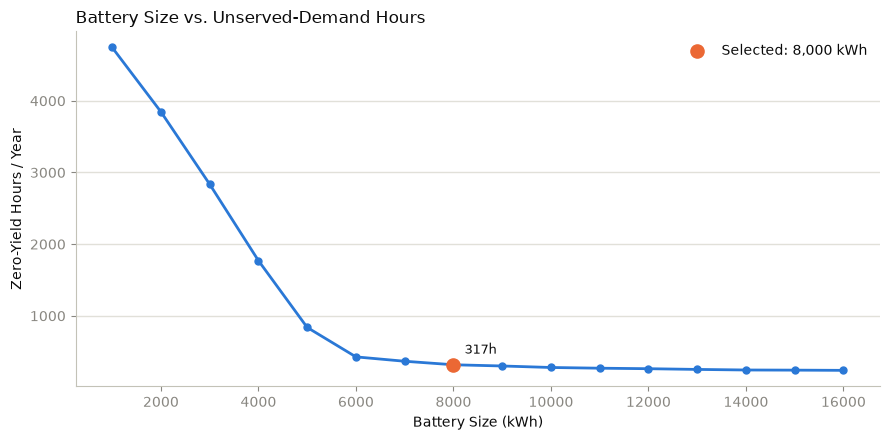

As expected, this is a diminishing-returns curve: early kWh of battery capacity buy back many hours of unserved
demand, and the curve flattens as the battery grows large enough to ride out most of the year's deficit blocks.


In [21]:
fig, ax = plt.subplots(figsize=(9, 4.5))  # subplots(): create a new figure and axes to draw the chart on
ax.plot(sensitivity["battery_kwh"], sensitivity["zero_yield_hours"], color=CATEGORY_COLORS["A"], linewidth=2, marker="o", markersize=5)  # plot(): single-series trend, so sequential blue rather than the categorical palette

# Mark the currently-selected size (from default_pv_parameters) directly on the curve
ax.scatter([project_battery_kwh], [project_zero_hours], color=CATEGORY_COLORS["B"], s=90, zorder=5, label=f"Selected: {project_battery_kwh:,.0f} kWh")  # scatter(): highlight the chosen point in the accent color
ax.annotate(f"{project_zero_hours}h", (project_battery_kwh, project_zero_hours), textcoords="offset points", xytext=(8, 8), fontsize=9, color=TEXT_PRIMARY)

ax.set_xlabel("Battery Size (kWh)")
ax.set_ylabel("Zero-Yield Hours / Year")
ax.set_title("Battery Size vs. Unserved-Demand Hours", loc="left", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(AXIS_INK)
ax.yaxis.grid(True, color=GRIDLINE, linewidth=1, zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

print("As expected, this is a diminishing-returns curve: early kWh of battery capacity buy back many hours of unserved")
print("demand, and the curve flattens as the battery grows large enough to ride out most of the year's deficit blocks.")

## 4.15 Saving results

Two outputs, for later steps to build on: the full per-hour generation/battery table (Step 5's LCOE needs total PV generation; a future "system operation" view could chart SOC over time), and a small results summary (the sizing numbers Step 6's summary table will need).

In [22]:
# Full per-hour table: demand, irradiance, generation, deficit/surplus, and simulated battery SOC — all using this
# project's own numbers (corrected demand, default PV parameters) from §4.13.
pv_battery_simulation = pd.DataFrame({
    "hour_of_year": project_hourly.index,
    "demand_wh": project_hourly.values,
    "ghi_wm2": project_ghi.values,
    "egen_wh": project_egen.values,
    "delta_e_wh": project_blocks["delta_e_wh"].values,
    "block_id": project_blocks["block_id"].values,
    "battery_soc_wh": project_soc,
})
pv_battery_simulation.to_csv(DATA_DIR / "pv_battery_simulation_2026.csv", index=False)  # to_csv(): save the full per-hour table
print("Saved to:", (DATA_DIR / "pv_battery_simulation_2026.csv").resolve())

# Small results summary — the scalar sizing outcomes later steps (Step 5 LCOE, Step 6 summary table) will need.
pv_battery_sizing_results = pd.DataFrame([
    {"result": "annual_egen_wh", "value": project_egen.sum(), "unit": "Wh", "description": "Total annual PV generation at the selected Ppeak"},
    {"result": "annual_demand_wh", "value": project_hourly.sum(), "unit": "Wh", "description": "Total annual demand (Steps 2-3, corrected calendar)"},
    {"result": "worst_deficit_block_wh", "value": project_worst_block, "unit": "Wh", "description": "Worst single contiguous deficit run — drives battery sizing"},
    {"result": "battery_capacity_kwh", "value": project_battery_kwh, "unit": "kWh", "description": "Sized battery capacity (DoD 0.80, quality factor 0.85)"},
    {"result": "zero_yield_hours", "value": project_zero_hours, "unit": "hours/year", "description": "Hours per year the battery is fully depleted (unserved demand) at the sized capacity"},
])
pv_battery_sizing_results.to_csv(DATA_DIR / "pv_battery_sizing_results_2026.csv", index=False)
print("Saved to:", (DATA_DIR / "pv_battery_sizing_results_2026.csv").resolve())
pv_battery_sizing_results

Saved to: /home/claude/rural-electrification/data/pv_battery_simulation_2026.csv
Saved to: /home/claude/rural-electrification/data/pv_battery_sizing_results_2026.csv


,result,value,unit,description
0,annual_egen_wh,3.839823e+09,Wh,Total annual PV generation at the selected Ppeak
1,annual_demand_wh,3.440338e+09,Wh,"Total annual demand (Steps 2-3, corrected cale..."
2,worst_deficit_block_wh,-7.141922e+06,Wh,Worst single contiguous deficit run — drives b...
3,battery_capacity_kwh,8.000000e+03,kWh,"Sized battery capacity (DoD 0.80, quality fact..."
4,zero_yield_hours,3.170000e+02,hours/year,Hours per year the battery is fully depleted (...


## 4.16 Summary

- **PV generation model** (`compute_egen()`): Ppeak × [G(i)/1000] × Q / Iqc, validated to the exact Wh against the workbook's own cached annual total (3,839,823,405 Wh).
- **Deficit/surplus blocks** (`compute_delta_e_and_blocks()`, `block_sums()`): hourly Delta-E grouped into contiguous same-sign runs, validated to the exact Wh against the workbook's worst/best block (Q7/R7: -7,141,922 / 8,860,118 Wh).
- **Battery sizing & SOC simulation** (`size_battery()`, `simulate_battery_soc()`, `count_zero_yield_hours()`): validated to reproduce the workbook's battery size and zero-yield-hours exactly (8,000 kWh, 384 h) when using the workbook's own demand and its undocumented 0.90 factor.
- **This project's own numbers** (§4.13): switching to the corrected demand (Steps 2-3) and the decided 0.85 battery quality factor gives **8,000 kWh** (unchanged — same MROUND bracket) and **317 zero-yield hours** (down from 384). The two changes were isolated: the entire drop comes from the calendar fix reducing overall demand, not from the quality-factor change, which alone doesn't move either number at this battery size.
- **Battery-size sensitivity curve** (§4.14, `battery_size_sensitivity()`): the interactive sweep the workbook doesn't have — the clear diminishing-returns shape lets a user see the tradeoff before picking a size; becomes a live-updating slider in the Streamlit app.
- **All five scalar inputs are user-editable** via `data/default_pv_parameters.csv` / `PV_Parameters_Template.xlsx` (Excel round-trip, same validated pattern as every other dataset): `performance_ratio_Q`, `reference_irradiance_iqc_kwm2`, `ppeak_w`, `battery_dod`, `battery_quality_factor` — with the `Q` vs. `battery_quality_factor` naming kept deliberately distinct despite the shared 0.85 default.
- New files in `data/`: `default_pv_parameters.csv`, `PV_Parameters_Template.xlsx`, `pv_battery_simulation_2026.csv`, `pv_battery_sizing_results_2026.csv`.

**Step 4 (Solar Resource & PV/Battery Sizing) is now done.** One open item carried over from §4.9: the live PVGIS/NASA POWER fetch itself still needs to be confirmed on your machine (or a deployed server) — the sandbox network restriction only let the fallback path be exercised here. Next: Step 5 — Cost/BOQ/LCOE, using this step's `annual_egen_wh` as the LCOE denominator per your correction (LCOE = Total Cost / Total PV Generation).